# **Proyecto IA**
#**Primer entrega**

-Nelson Andres Urrea Calvo 2221115\
-Jhon Jairo Velandia Ramirez 2220028\
-Cristian Ferney Rivera González 2234509



# Descripción del dataset:
**Online Learning Engagement Dataset** : https://uci-ics-mlr-prod.aws.uci.edu/dataset/697/p…%2Band%2Bacademic%2Bsuccess?

Este conjunto de datos contiene información que representa la participación y el comportamiento de aprendizaje de los estudiantes en un entorno de educación en línea. Incluye diversas características relacionadas con la demografía estudiantil, los hábitos de estudio, la actividad en la plataforma y el rendimiento académico.




# PROBLEMATICA
El problema abordado en este análisis es la predicción del rendimiento académico y la permanencia estudiantil mediante el uso de técnicas de Machine Learning. A partir de variables relacionadas con el comportamiento del estudiante, como las horas de estudio, la frecuencia de acceso, la participación en actividades, la interacción en la plataforma y el desempeño en evaluaciones, se busca construir un modelo capaz de clasificar a los estudiantes según su resultado académico.
De esta manera, se pretende identificar si un estudiante tiene probabilidad de abandonar sus estudios o de completar su proceso formativo.


## librerias

In [ ]:

import os
import numpy as np
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Montar el drive

In [ ]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Proyecto/Segundo dataset/data.csv';
df = pd.read_csv(path, sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mostrar información básica
print("df shape:", df.shape)
df
print("\nPrimeras filas del df:")
display(df.head())


df shape: (4424, 37)

Primeras filas del df:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

##INFORMACION DE DATOS

## Valores nulos en cada columna

In [ ]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


##Valores maximos y minimos de cada columna

In [ ]:
df_num = df.select_dtypes(include="number")
resultado = pd.DataFrame({
    "max": df_num.max(),
    "min": df_num.min()
})
for col in df_num.columns:
    print(f"Columna {col}: max={df_num[col].max()}, min={df_num[col].min()}")

Columna Marital status: max=6, min=1
Columna Application mode: max=57, min=1
Columna Application order: max=9, min=0
Columna Course: max=9991, min=33
Columna Daytime/evening attendance	: max=1, min=0
Columna Previous qualification: max=43, min=1
Columna Previous qualification (grade): max=190.0, min=95.0
Columna Nacionality: max=109, min=1
Columna Mother's qualification: max=44, min=1
Columna Father's qualification: max=44, min=1
Columna Mother's occupation: max=194, min=0
Columna Father's occupation: max=195, min=0
Columna Admission grade: max=190.0, min=95.0
Columna Displaced: max=1, min=0
Columna Educational special needs: max=1, min=0
Columna Debtor: max=1, min=0
Columna Tuition fees up to date: max=1, min=0
Columna Gender: max=1, min=0
Columna Scholarship holder: max=1, min=0
Columna Age at enrollment: max=70, min=17
Columna International: max=1, min=0
Columna Curricular units 1st sem (credited): max=20, min=0
Columna Curricular units 1st sem (enrolled): max=26, min=0
Columna Curr

##Variable objetivo

"Dropout" Esta variable representa la deserción de los estudiantes en los cursos a partir de dos posible valores 2, 1 y 0  que significan si el estudiante ingreso, aprovo o abandono el curso respectivamente.

In [ ]:
df['Target'] = df['Target'].replace({
    'Graduate': 0,
    'Dropout': 1,
    'Enrolled': 0
})

df['Target'].value_counts()

/tmp/ipykernel_31624/3125378057.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace({


,count
Target,
0,3003
1,1421


--- Análisis de la Variable Dropout ---
El valor '0' tiene una frecuencia de 3003 muestras (67.9%).
El valor '1' tiene una frecuencia de 1421 muestras (32.1%).


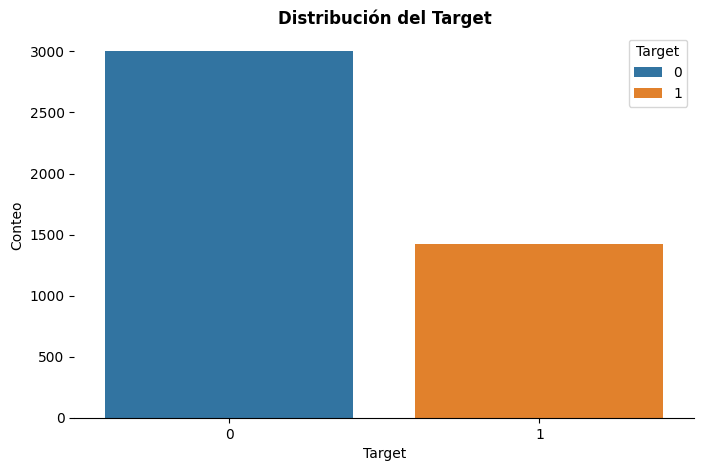

In [ ]:
# Preparación de la figura usando Seaborn + Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Target', hue = 'Target', ax=ax)

# Refinamiento con Matplotlib
ax.set_title('Distribución del Target', fontweight='bold')
ax.set_xlabel('Target')
ax.set_ylabel('Conteo')
sns.despine(left=True)

# Cálculo de estadísticas
total = len(df)
stats_dropout = df['Target'].value_counts().to_dict()

print("--- Análisis de la Variable Dropout ---")
for valor, conteo in stats_dropout.items():
    porcentaje = (conteo / total) * 100
    print(f"El valor '{valor}' tiene una frecuencia de {conteo} muestras ({porcentaje:.1f}%).")

plt.show()

## Relacion entre variables



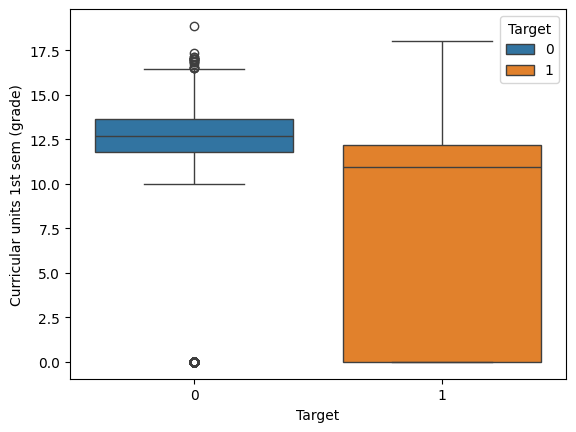

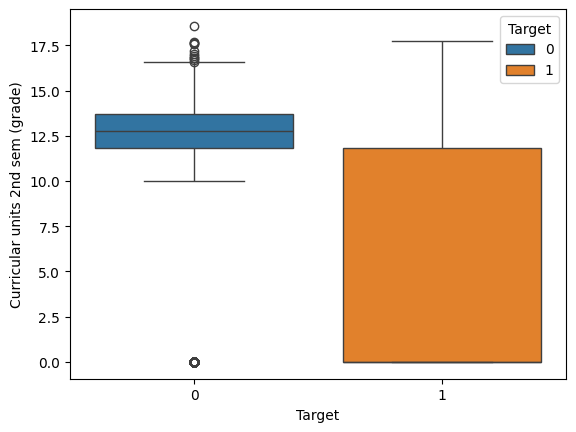

In [ ]:
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df, hue = 'Target')
plt.show()

sns.boxplot(x='Target', y='Curricular units 2nd sem (grade)', data=df, hue = 'Target')
plt.show()

In [ ]:
grouped_grades = df.groupby('Target')[['Age at enrollment', 'Gender', 'Application mode']].mean()
print(grouped_grades)

        Age at enrollment    Gender  Application mode
Target                                               
0               21.938395  0.284715         16.282384
1               26.068966  0.493315         23.712878


In [ ]:
print(f"Minimum age at enrollment: {df['Age at enrollment'].min()}")
print(f"Maximum age at enrollment: {df['Age at enrollment'].max()}")

Minimum age at enrollment: 17
Maximum age at enrollment: 70


## **Diagrama de barras**

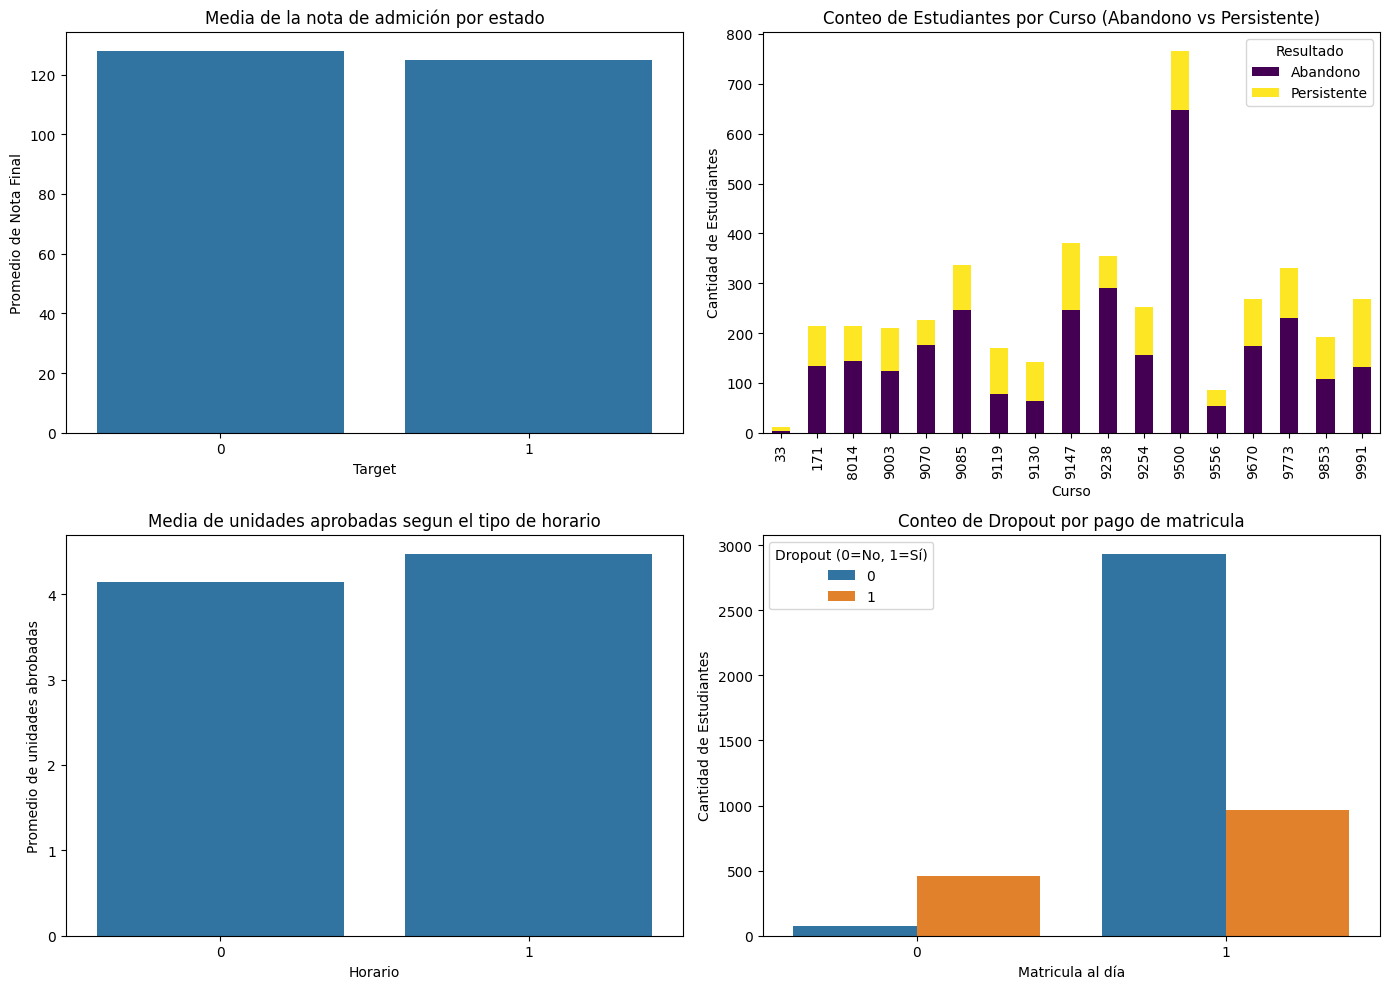

In [ ]:
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Agrupar por Target
Admission_grade = df.groupby('Target')['Admission grade'].mean().reset_index()

# Gráfica 1: Media de Final Grade por País
sns.barplot(data=Admission_grade, x='Target', y='Admission grade', ax=axes[0])
axes[0].set_title('Media de la nota de admición por estado')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Promedio de Nota Final')


# New logic for the second plot (Conteo de Estudiantes por Curso - Stacked)
# Create a temporary DataFrame to avoid modifying the original df for this specific plot
plot_df_g2 = df.copy()

# Create a 'target_category' column for grouping
# Map Target 1 and 2 to 'Persistente', and Target 0 to 'Abandono'
plot_df_g2['target_category'] = plot_df_g2['Target'].map({0: 'Abandono', 1: 'Persistente', 2: 'Persistente'})

# Group by Course and the new target_category, then count and unstack for stacking
course_stacked_counts = plot_df_g2.groupby(['Course', 'target_category']).size().unstack(fill_value=0)

# Gráfica 2: Conteo de Estudiantes por Curso (Apilado: Abandono vs Persistente)
course_stacked_counts.plot(kind='bar', stacked=True, ax=axes[1], cmap='viridis') # Using cmap for distinct colors
axes[1].set_title('Conteo de Estudiantes por Curso (Abandono vs Persistente)')
axes[1].set_xlabel('Curso')
axes[1].set_ylabel('Cantidad de Estudiantes')
axes[1].legend(title='Resultado')

units_aproved_by_daytime = df.groupby('Daytime/evening attendance')['Curricular units 2nd sem (approved)'].mean().reset_index()

# Gráfica 3: Media de Final Grade por Tipo de Dispositivo
sns.barplot(data=units_aproved_by_daytime, x='Daytime/evening attendance', y='Curricular units 2nd sem (approved)',  ax=axes[2])
axes[2].set_title('Media de unidades aprobadas segun el tipo de horario')
axes[2].set_xlabel('Horario')
axes[2].set_ylabel('Promedio de unidades abrobadas')


# Agrupar por estado del pago de la matricula y contar los valores de dropout (0 1 y 2)
tuition_state_counts = df['Target'].groupby(df['Tuition fees up to date']).value_counts().reset_index(name='count_of_dropout')

# Gráfica 4: Conteo de Dropout por estado del pago de la matricula
sns.barplot(data=tuition_state_counts, x='Tuition fees up to date', y='count_of_dropout', hue='Target', ax=axes[3])
axes[3].set_title('Conteo de Dropout por pago de matricula')
axes[3].set_xlabel('Matricula al día')
axes[3].set_ylabel('Cantidad de Estudiantes')
axes[3].legend(title='Dropout (0=No, 1=Sí)')


plt.tight_layout()
plt.show()

In [ ]:
course_target_counts = df.groupby(['Target','Gender']).size().unstack(fill_value=0)
print(course_target_counts)

Gender     0    1
Target           
0       2148  855
1        720  701


In [ ]:
grouped_grades_by_course_target = df.groupby(['Course', 'Target'])[['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']].mean()
display(grouped_grades_by_course_target)

Curricular units 1st sem (grade)  \
Course Target                                     
33     0                              13.097240   
       1                               7.910038   
171    0                               2.890640   
       1                               0.738485   
8014   0                              12.550217   
       1                               6.553199   
9003   0                              12.592061   
       1                               7.182419   
9070   0                              12.923402   
       1                               9.192994   
9085   0                              13.247406   
       1                               8.050040   
9119   0                              11.040415   
       1                               6.466949   
9130   0                              12.895651   
       1                               7.814403   
9147   0                              11.710193   
       1                               7.203374   
9238   0                              12.179737   
       1                               7.033700   
9254   0                              12.367961   
       1                               7.359995   
9500   0                              13.324189   
       1                               7.745677   
9556   0                              11.446485   
       1                               8.548247   
9670   0                              12.853220   
       1                               8.559737   
9773   0                              12.981004   
       1                               8.764875   
9853   0                              12.924733   
       1                               9.639806   
9991   0                              11.934527   
       1                               6.354282   

               Curricular units 2nd sem (grade)  
Course Target                                    
33     0                              12.798214  
       1                               7.093750  
171    0                               2.916490  
       1                               0.730820  
8014   0                              12.416533  
       1                               4.481433  
9003   0                              12.264594  
       1                               5.457184  
9070   0                              12.507310  
       1                               6.696125  
9085   0                              12.871803  
       1                               6.465093  
9119   0                              11.705564  
       1                               6.313859  
9130   0                              13.231293  
       1                               6.819017  
9147   0                              11.793484  
       1                               5.867219  
9238   0                              12.329337  
       1                               5.698864  
9254   0                              12.447125  
       1                               5.835938  
9500   0                              13.414615  
       1                               6.534007  
9556   0                              12.913067  
       1                               4.711616  
9670   0                              13.025050  
       1                               6.417845  
9773   0                              12.990989  
       1                               6.583616  
9853   0                              12.618437  
       1                               7.982395  
9991   0                              12.317575  
       1                               6.221624

##**Histograma de frecuencias**

--- 4.1 Análisis de Distribuciones ---


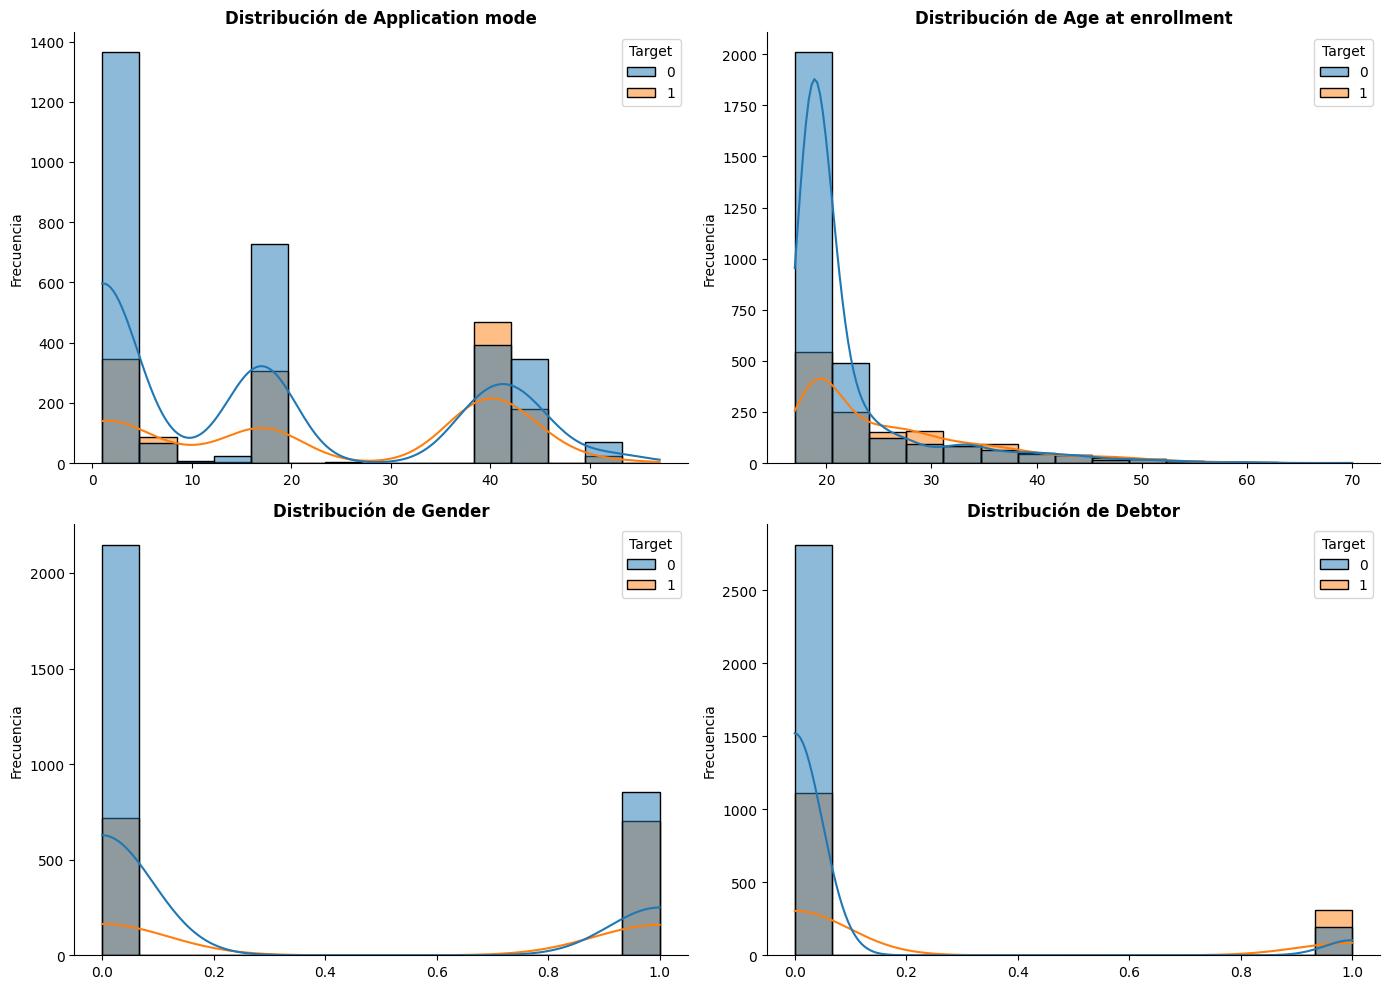

In [ ]:
features = ['Application mode', "Age at enrollment", "Gender","Debtor"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("--- 4.1 Análisis de Distribuciones ---")

for i, col in enumerate(features):
    # Base con Seaborn: Histograma + KDE para ver la forma de la campana
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], hue='Target', bins=15) # Corrected line

    # Refinamiento Matplotlib
    axes[i].set_title(f'Distribución de {col.capitalize()}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

##**Matriz de correlación**

In [ ]:
#20 variables con más correlación
numeric = df.select_dtypes(include=np.number).columns
cor = df[numeric].corr()
columnas = cor["Target"].sort_values(ascending=False).head(5).index.tolist()

In [ ]:
columnas

['Target', 'Age at enrollment', 'Debtor', 'Gender', 'Application mode']

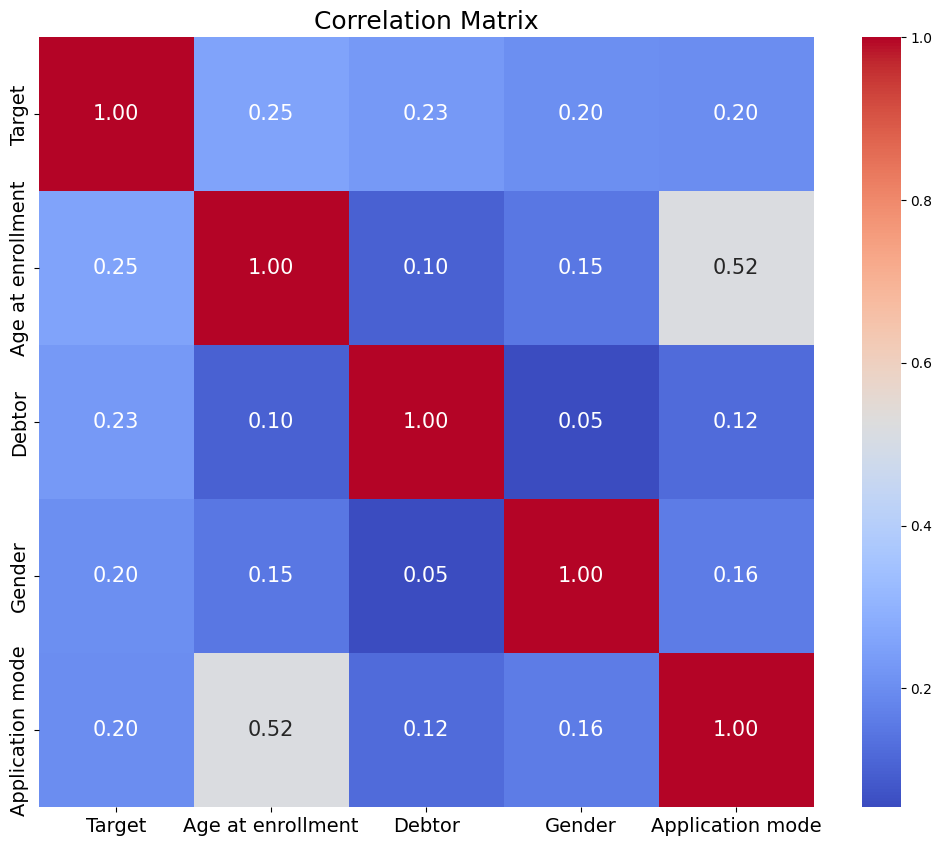

In [ ]:
numeric = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12.5, 10))
ax = sns.heatmap(df[columnas].corr(), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 15})
plt.title('Correlation Matrix', fontsize=18)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.show()

##**Pairplot**

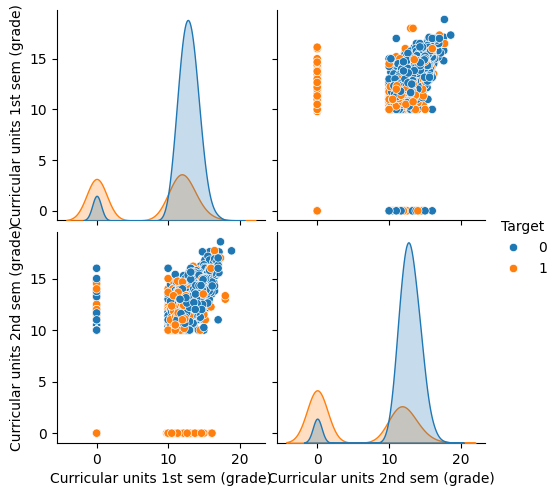

In [ ]:
df.columns = df.columns.str.strip() # Clean column names
sns.pairplot(df, vars=['Curricular units 1st sem (grade)',
 'Curricular units 2nd sem (grade)'], hue='Target')
plt.show()

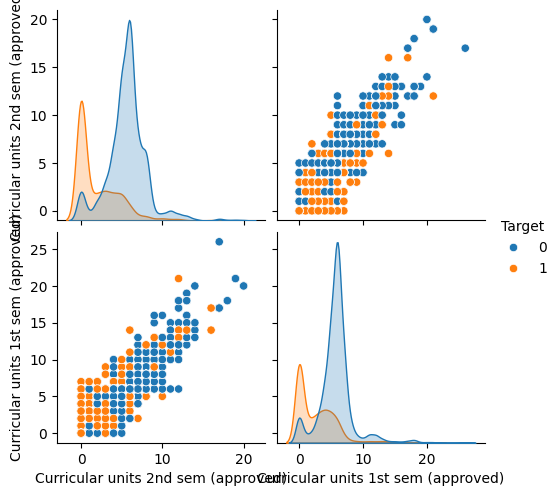

In [ ]:

sns.pairplot(df[['Curricular units 2nd sem (approved)','Target','Curricular units 1st sem (approved)']], hue='Target')
plt.show()

### Distribución de abandono y permanencia por curso

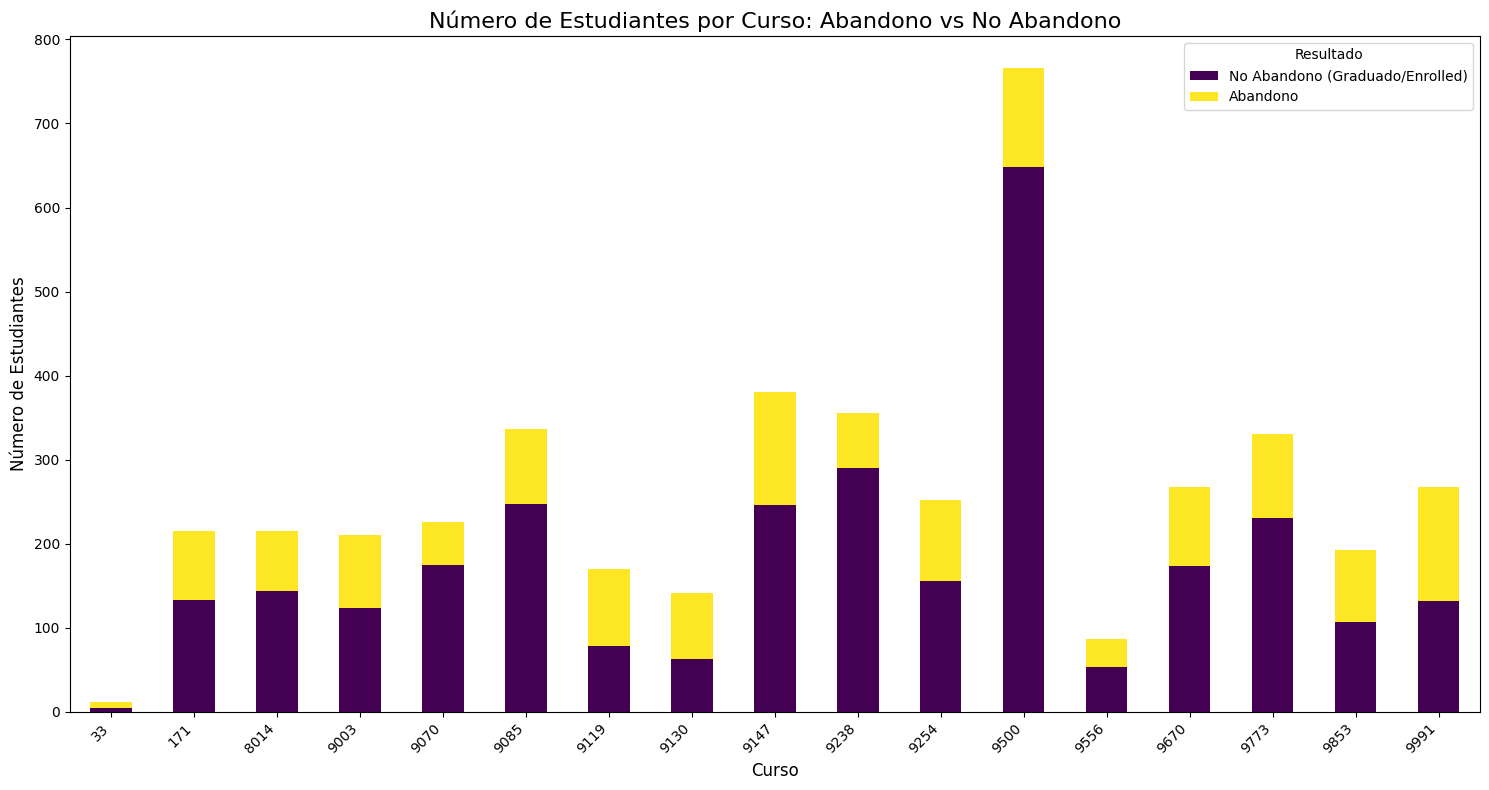

In [ ]:
course_target_counts = df.groupby(['Course', 'Target']).size().unstack(fill_value=0)

# Rename columns for better readability in the plot
course_target_counts = course_target_counts.rename(columns={0: 'No Abandono (Graduado/Enrolled)', 1: 'Abandono'})

# Plotting the stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))
course_target_counts.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

ax.set_title('Número de Estudiantes por Curso: Abandono vs No Abandono', fontsize=16)
ax.set_xlabel('Curso', fontsize=12)
ax.set_ylabel('Número de Estudiantes', fontsize=12)
ax.legend(title='Resultado', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()